Construire un jeu de données d’analyse au niveau pays, centré sur la consommation de « Viande de Volailles », enrichi par des indicateurs PESTEL (variables politiques, économiques, sociales, technologiques, environnementales, légales et métriques opérationnelles). Sélectionner au moins 100 pays couvrant au minimum 60 % de la population mondiale. Produire un fichier Excel final contenant les indicateurs par pays et par année, incluant le revenu moyen par habitant (fichier externe à joindre), et documenter toutes les étapes de nettoyage et d’agrégation avant analyse.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# Charger les datas
df_dispo = pd.read_csv('/content/drive/MyDrive/data_P11/DisponibiliteAlimentaire_2017.csv')
df_pop = pd.read_csv('/content/drive/MyDrive/data_P11/Population_2000_2018.csv')
df_pib = pd.read_csv('/content/drive/MyDrive/data_P11/pibParHabitant2017.csv')

DISPONIBILITE ALIMENTAIRE

In [5]:
df_dispo.head()


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64

<Axes: >

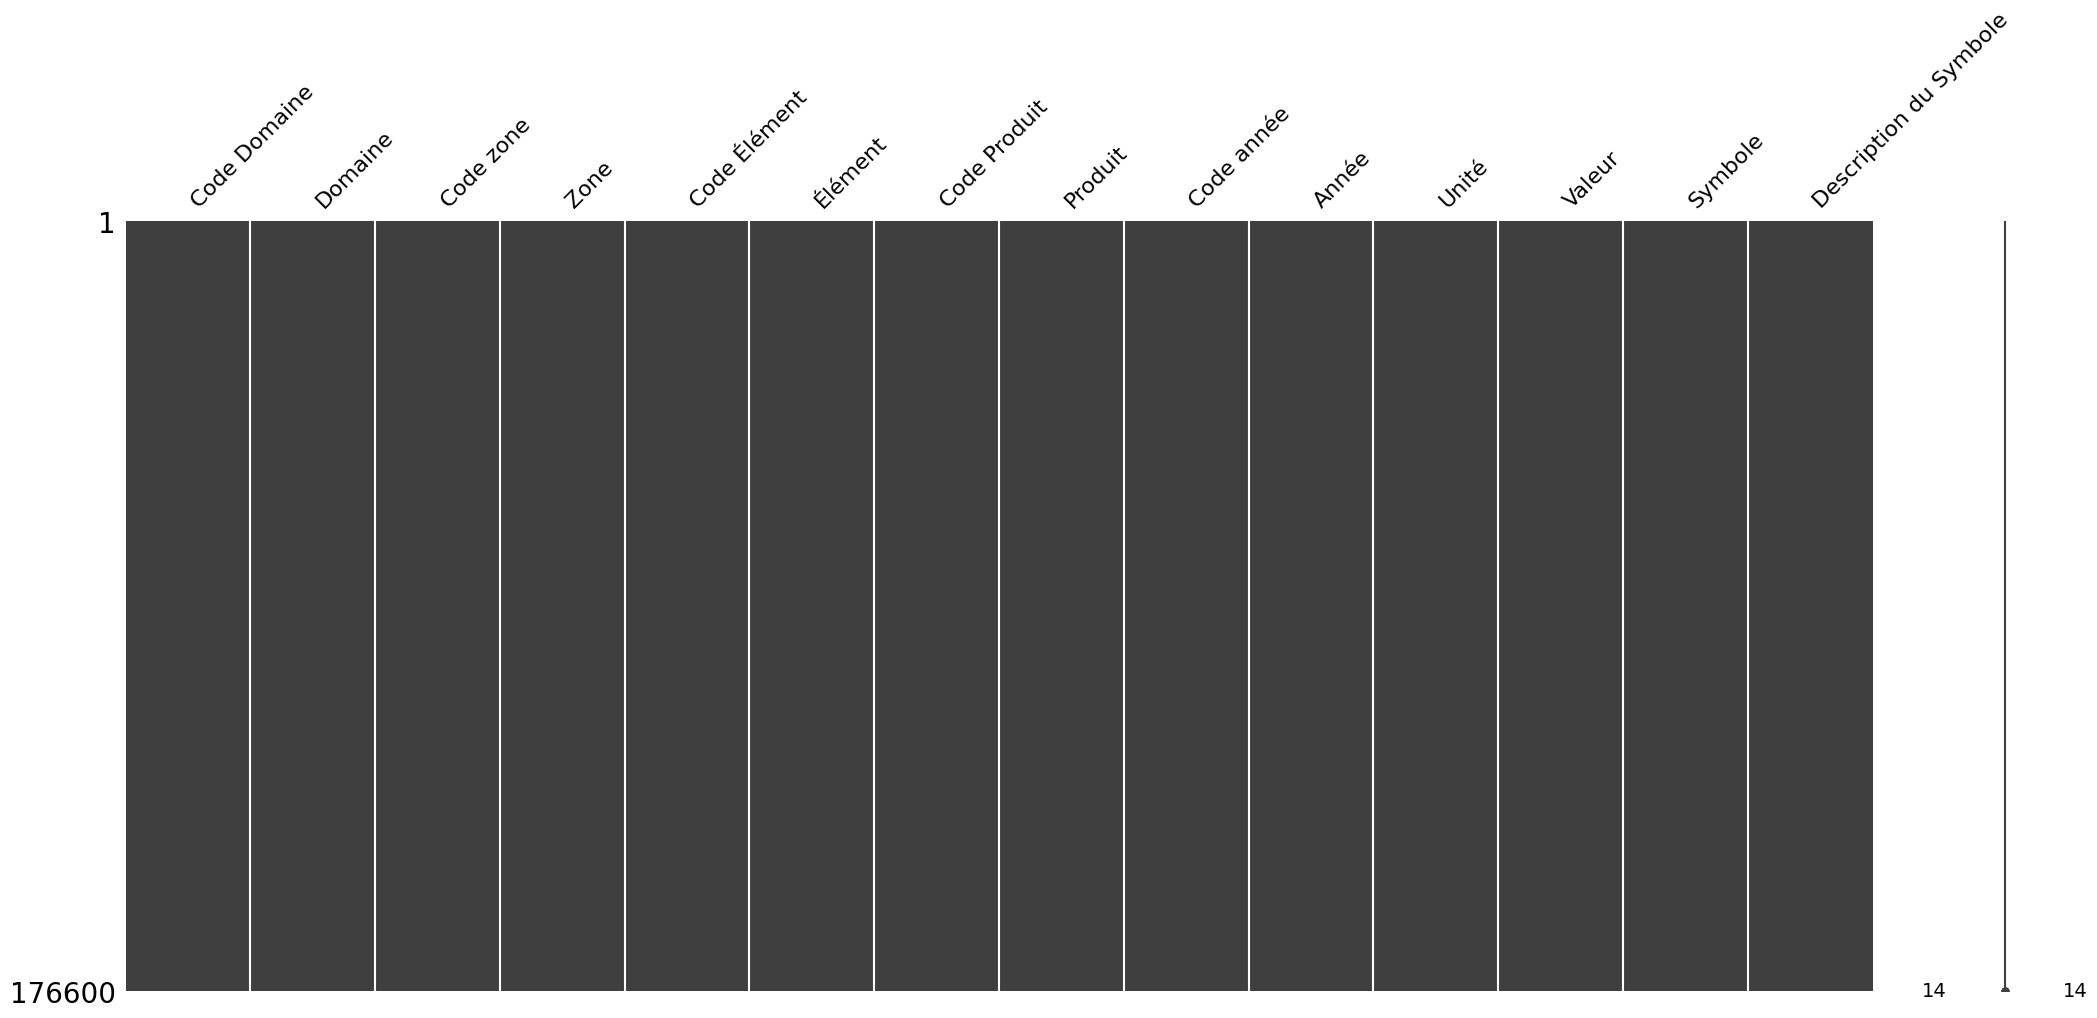

In [6]:
df_dispo.info()
msno.matrix(df_dispo)

In [7]:
# Vérification des doublons

df_doublons = df_dispo[df_dispo.duplicated(
    keep=False
)].copy()
len(df_doublons)

0

In [8]:
subset_cols = ['Zone','Élément', 'Année']

df_dispo.drop_duplicates(
    subset=subset_cols,
    keep=False
)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
7061,FBS,Nouveaux Bilans Alimentaire,8,Antigua-et-Barbuda,5527,Semences,2744,Oeufs,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
20951,FBS,Nouveaux Bilans Alimentaire,17,Bermudes,5072,Variation de stock,2764,"Poissons Marins, Autres",2017,2017,Milliers de tonnes,0.0,S,Données standardisées
34794,FBS,Nouveaux Bilans Alimentaire,128,Chine - RAS de Macao,5527,Semences,2744,Oeufs,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
45853,FBS,Nouveaux Bilans Alimentaire,72,Djibouti,5527,Semences,2514,Maïs et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
50807,FBS,Nouveaux Bilans Alimentaire,225,Émirats arabes unis,5527,Semences,2744,Oeufs,2017,2017,Milliers de tonnes,6.0,S,Données standardisées
90800,FBS,Nouveaux Bilans Alimentaire,83,Kiribati,5131,Traitement,2560,Coco (Incl Coprah),2017,2017,Milliers de tonnes,36.0,S,Données standardisées
91223,FBS,Nouveaux Bilans Alimentaire,83,Kiribati,5527,Semences,2744,Oeufs,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
102487,FBS,Nouveaux Bilans Alimentaire,132,Maldives,5131,Traitement,2560,Coco (Incl Coprah),2017,2017,Milliers de tonnes,0.0,S,Données standardisées
109213,FBS,Nouveaux Bilans Alimentaire,141,Mongolie,5171,Alimentation pour touristes,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
123899,FBS,Nouveaux Bilans Alimentaire,235,Ouzbékistan,5072,Variation de stock,2761,Poissons Eau Douce,2017,2017,Milliers de tonnes,0.0,S,Données standardisées


In [9]:
# nettoyer noms de colonnes invisibles et espaces dans les valeurs textuelles
df_dispo.columns = [c.strip() for c in df_dispo.columns]
for c in ['Zone','Élément','Valeur','Année']:
    if c in df_dispo.columns and df_dispo[c].dtype == object:
        df_dispo[c] = df_dispo[c].str.strip()
# convertir types si nécessaire
df_dispo['Année'] = pd.to_numeric(df_dispo['Année'], errors='coerce')
df_dispo['Valeur'] = pd.to_numeric(df_dispo['Valeur'], errors='coerce')


In [10]:
df_dispo_pivot = df_dispo.pivot_table(
    index=['Zone', 'Produit'],
    columns='Élément',
    values='Valeur',
    aggfunc='first'   # garde la première valeur non nulle pour chaque (Zone, Élément)
).reset_index().rename_axis(columns=None)

df_dispo_pivot

,Zone,Produit,Alimentation pour touristes,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Résidus,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,NaN,NaN,NaN,5.0,1.47,0.19,0.64,53.0,NaN,6.0,53.0,NaN,48.0,0.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",NaN,NaN,NaN,1.0,1.32,0.01,0.02,50.0,0.0,33.0,48.0,2.0,17.0,0.0,NaN,NaN,NaN
2,Afghanistan,"Alcool, non Comestible",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0
3,Afghanistan,Aliments pour enfants,NaN,NaN,NaN,1.0,0.10,0.01,0.04,4.0,NaN,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Ananas et produits,NaN,NaN,NaN,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,NaN,NaN,-0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16042,Îles Salomon,Viande de Suides,-0.0,NaN,NaN,44.0,4.49,4.24,1.38,3.0,NaN,0.0,3.0,NaN,2.0,0.0,NaN,NaN,-0.0
16043,Îles Salomon,Viande de Volailles,-0.0,NaN,NaN,18.0,4.45,1.31,1.51,3.0,0.0,6.0,3.0,NaN,0.0,0.0,NaN,NaN,3.0
16044,Îles Salomon,"Viande, Autre",-0.0,NaN,NaN,0.0,0.01,0.00,0.00,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0
16045,Îles Salomon,Vin,-0.0,NaN,NaN,0.0,0.25,0.00,0.00,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0


<Axes: >

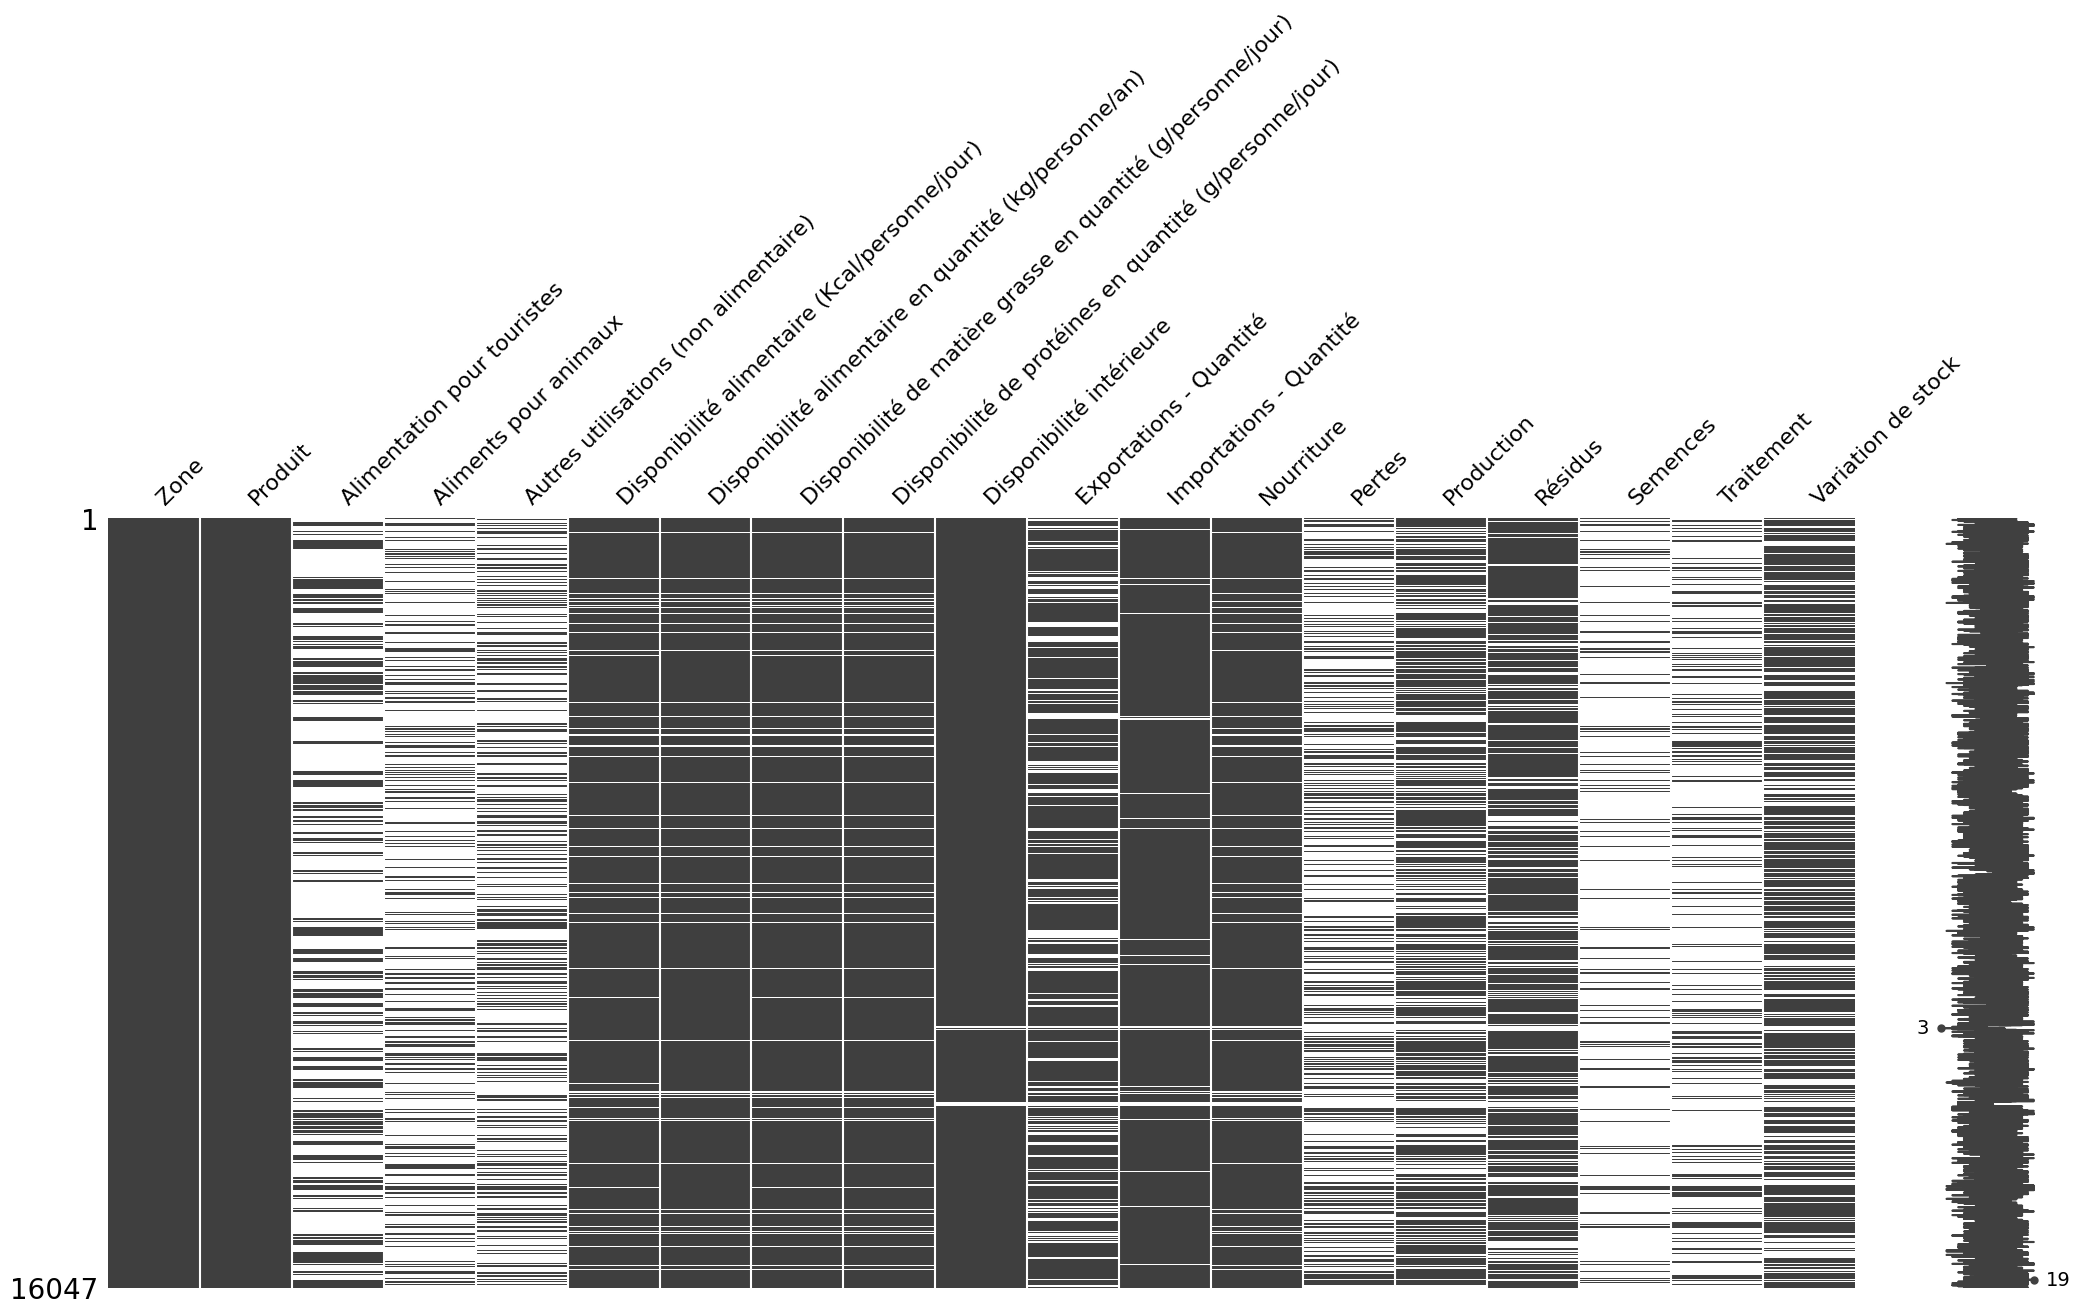

In [11]:
msno.matrix(df_dispo_pivot)

In [12]:
na_summary = pd.DataFrame({
    'missing_count': df_dispo_pivot.isna().sum(),
    'missing_pct': df_dispo_pivot.isna().mean() * 100,
    'total': len(df_dispo_pivot)
})
na_summary = na_summary.sort_values('missing_pct', ascending=False)
na_summary


,missing_count,missing_pct,total
Semences,13935,86.838661,16047
Traitement,12501,77.902412,16047
Aliments pour animaux,11859,73.901664,16047
Autres utilisations (non alimentaire),10755,67.021873,16047
Alimentation pour touristes,10487,65.351779,16047
Pertes,10234,63.775160,16047
Production,5713,35.601670,16047
Variation de stock,4748,29.588085,16047
Exportations - Quantité,3934,24.515486,16047
Résidus,3480,21.686297,16047


In [13]:
# Si na_summary a les noms de colonnes en index, on les remet en colonne
if na_summary.index.name is None or na_summary.index.name != 'column':
    na_plot = na_summary.reset_index().rename(columns={'index': 'column'})
else:
    na_plot = na_summary.reset_index().rename(columns={na_summary.index.name: 'column'})

# Gérer colonnes sans NaN (option)
na_plot_all = na_plot.copy()
na_plot = na_plot[na_plot['missing_pct'] > 0].copy()  # garder seulement >0 ; enlever ce filtre si vous voulez tout

# Option: limiter l'affichage aux top N colonnes les plus affectées
top_n = 30  # mettre None pour tout afficher
if top_n is not None:
    na_plot = na_plot.sort_values('missing_pct', ascending=False).head(top_n)

# Couleur selon seuil
threshold = 40.0
na_plot['severity'] = na_plot['missing_pct'].apply(lambda x: f'>= {int(threshold)}%' if x >= threshold else f'< {int(threshold)}%')

# Construction du graphique
fig = px.bar(
    na_plot.sort_values('missing_pct'),          # tri asc pour barres horizontales lisibles
    x='missing_pct',
    y='column',
    orientation='h',
    color='severity',
    color_discrete_map={f'>= {int(threshold)}%': '#d62728', f'< {int(threshold)}%': '#1f77b4'},
    labels={'missing_pct': 'Pourcentage de NaN (%)', 'column': 'Colonne'},
    hover_data={'missing_count': True, 'missing_pct': ':.2f', 'total': True},
    title=f'Pourcentage de valeurs manquantes par colonne (top {top_n if top_n else "all"})'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    bargap=0.12,
    height=600,
    legend_title_text='Seuil',
    xaxis_tickformat=',.1f'
)

# Cas où il n'y a aucune colonne avec NaN
if na_plot.empty:
    print("Aucune colonne avec des valeurs manquantes (missing_pct = 0 pour toutes les colonnes).")
else:
    fig.show()


In [14]:
# cols_keep doit contenir les noms exacts présents dans df_dispo_pivot.columns
cols_keep = [
    'Zone', 'Produit', 'Disponibilité alimentaire en quantité (kg/personne/an)',
    'Disponibilité intérieure', 'Importations - Quantité',
    'Exportations - Quantité', 'Production'
]

# Conserver seulement les colonnes existantes dans df_dispo_pivot
cols_present = [c for c in cols_keep if c in df_dispo_pivot.columns]

# Option 1 : réassigner en gardant l'ordre de cols_present
df_dispo_vf = df_dispo_pivot[cols_present].copy()

# Option 2 : si vous voulez signaler les colonnes manquantes
missing = [c for c in cols_keep if c not in cols_present]
if missing:
    print("Colonnes demandées absentes du pivot :", missing)


In [15]:
df_dispo_vf_filtered = df_dispo_vf.query("Produit == 'Viande de Volailles'")
df_dispo_vf_filtered

,Zone,Produit,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production
78,Afghanistan,Viande de Volailles,1.53,57.0,29.0,NaN,28.0
173,Afrique du Sud,Viande de Volailles,35.69,2118.0,514.0,63.0,1667.0
265,Albanie,Viande de Volailles,16.36,47.0,38.0,0.0,13.0
357,Algérie,Viande de Volailles,6.38,277.0,2.0,0.0,275.0
452,Allemagne,Viande de Volailles,19.47,1739.0,842.0,646.0,1514.0
...,...,...,...,...,...,...,...
15668,Émirats arabes unis,Viande de Volailles,43.47,412.0,433.0,94.0,48.0
15765,Équateur,Viande de Volailles,19.31,341.0,0.0,0.0,340.0
15860,États-Unis d'Amérique,Viande de Volailles,55.68,18266.0,123.0,3692.0,21914.0
15954,Éthiopie,Viande de Volailles,0.13,14.0,1.0,NaN,14.0


POPULATION

In [16]:
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   object 
 1   Domaine                 4411 non-null   object 
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   object 
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   object 
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   object 
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   object 
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   object 
 13  Description du Symbole  4411 non-null   object 
 14  Note                    258 non-null    

<Axes: >

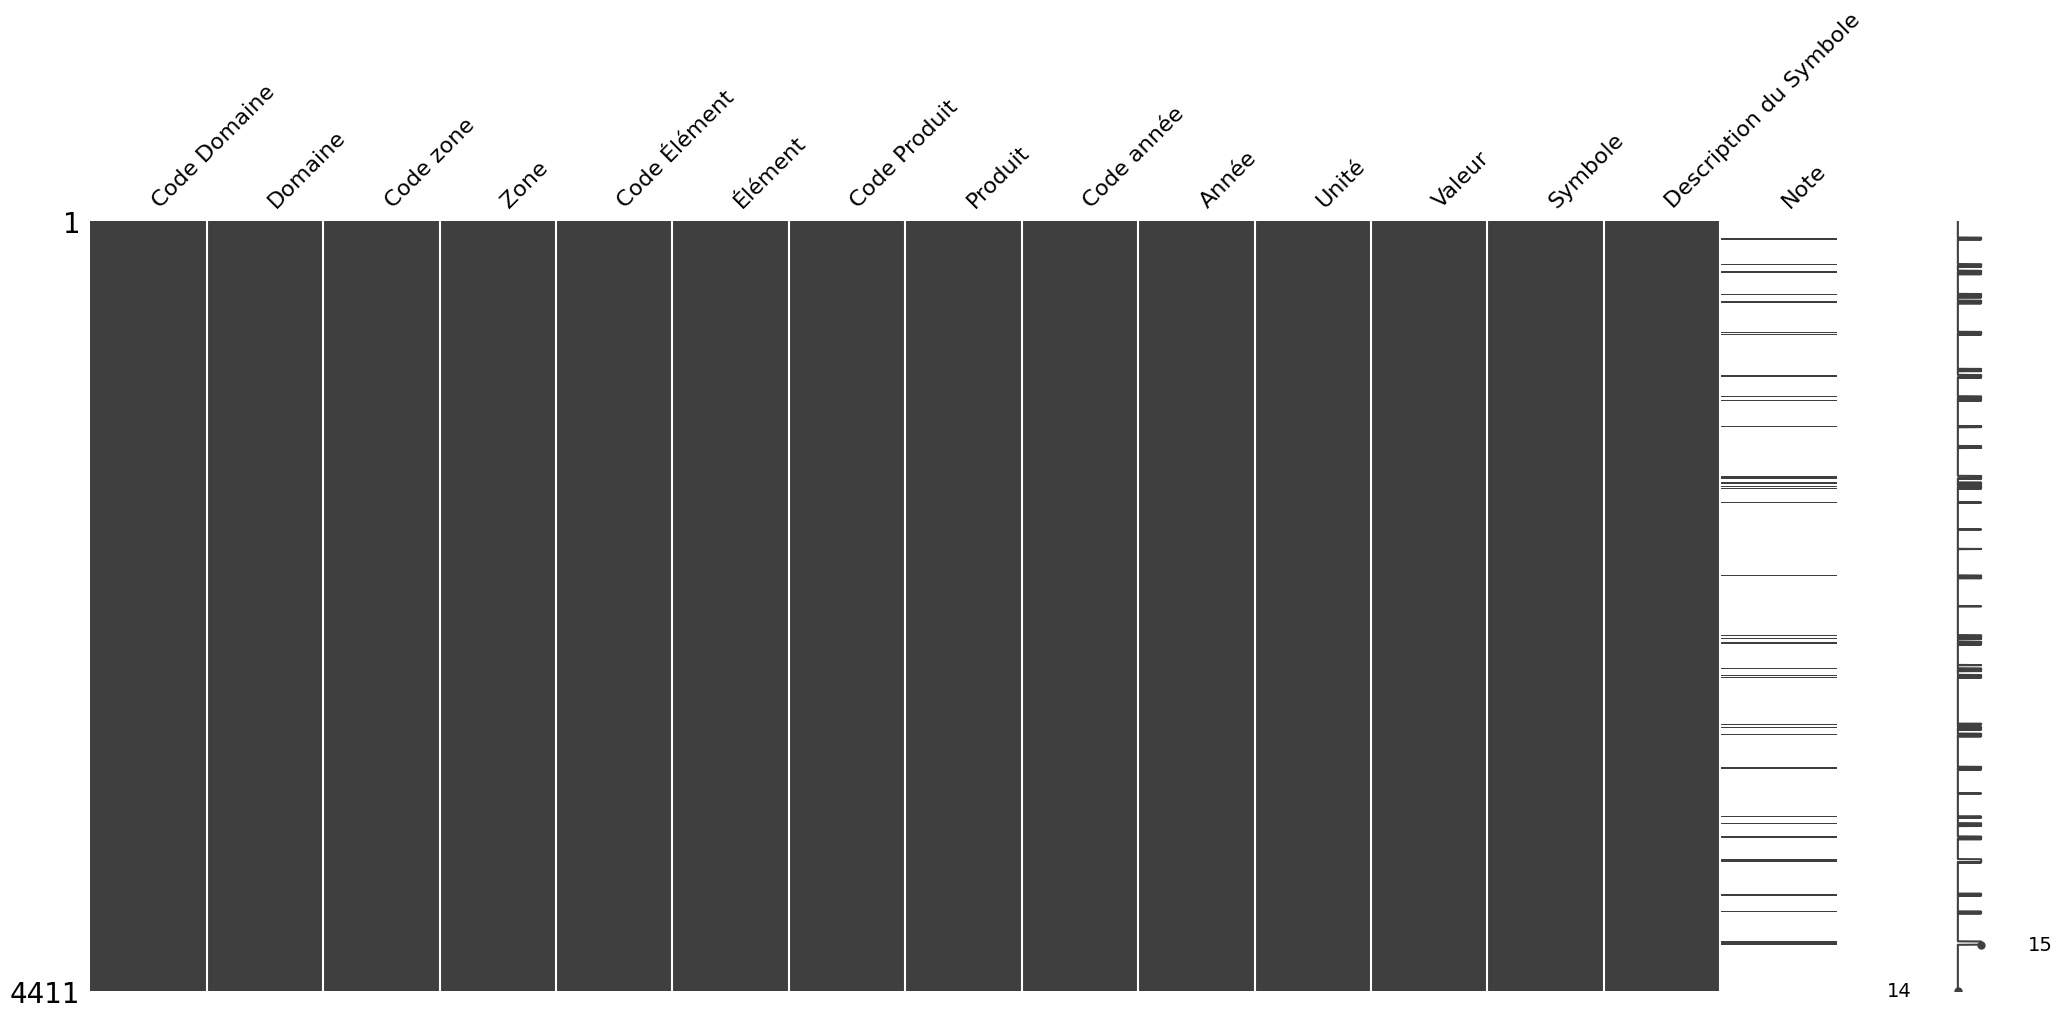

In [17]:
msno.matrix(df_pop)

In [18]:
# filtrer sur l'année 2017

df_pop_2017 = df_pop[df_pop['Année'] == 2017]
df_pop_2017

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,36296.113,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,57009.756,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,2884.169,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,41389.189,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,82658.409,X,Sources internationales sûres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4333,OA,Séries temporelles annuelles,236,Venezuela (République bolivarienne du),511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,29402.484,X,Sources internationales sûres,NaN
4352,OA,Séries temporelles annuelles,237,Viet Nam,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,94600.648,X,Sources internationales sûres,NaN
4371,OA,Séries temporelles annuelles,249,Yémen,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,27834.819,X,Sources internationales sûres,NaN
4390,OA,Séries temporelles annuelles,251,Zambie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,16853.599,X,Sources internationales sûres,NaN


In [19]:
# Sélectionner et renommer correctement
df_pop_2017_vf = df_pop_2017[['Zone', 'Valeur']].copy()
df_pop_2017_vf.rename(columns={'Valeur': 'Population'}, inplace=True)

In [20]:
# Nettoyage et conversion numérique
df_pop_2017_vf['Zone'] = df_pop['Zone'].astype(str).str.strip()
df_pop_2017_vf['Population'] = df_pop_2017_vf['Population'].astype(str).str.replace(r'\s+', '', regex=True).str.replace(',', '.', regex=True)
df_pop_2017_vf['Population'] = pd.to_numeric(df_pop_2017_vf['Population'], errors='coerce')

In [21]:
# Visualisation df après nettoyage
display(df_pop_2017_vf)
df_pop_2017_vf['Population'].dtype

,Zone,Population
17,Afghanistan,36296.113
36,Afrique du Sud,57009.756
55,Albanie,2884.169
74,Algérie,41389.189
93,Allemagne,82658.409
...,...,...
4333,Venezuela (République bolivarienne du),29402.484
4352,Viet Nam,94600.648
4371,Yémen,27834.819
4390,Zambie,16853.599


dtype('float64')

In [22]:
print("NaN population:", df_pop_2017_vf['Population'].isna().sum())
print("Valeurs négatives:", (df_pop_2017_vf['Population'] < 0).sum())


NaN population: 0
Valeurs négatives: 0


PIB PAR HABITANT

In [23]:
df_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            210 non-null    object 
 1   Domaine                 210 non-null    object 
 2   Code zone (M49)         210 non-null    int64  
 3   Zone                    210 non-null    object 
 4   Code Élément            210 non-null    int64  
 5   Élément                 210 non-null    object 
 6   Code Produit            210 non-null    int64  
 7   Produit                 210 non-null    object 
 8   Code année              210 non-null    int64  
 9   Année                   210 non-null    int64  
 10  Unité                   210 non-null    object 
 11  Valeur                  210 non-null    float64
 12  Symbole                 210 non-null    object 
 13  Description du Symbole  210 non-null    object 
 14  Note                    0 non-null      fl

In [24]:
df_pib

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,MK,Indicateurs macro,4,Afghanistan,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,533.339061,X,Chiffre de source externe,NaN
1,MK,Indicateurs macro,710,Afrique du Sud,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,6612.920015,X,Chiffre de source externe,NaN
2,MK,Indicateurs macro,8,Albanie,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,4492.285003,X,Chiffre de source externe,NaN
3,MK,Indicateurs macro,12,Algérie,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,4080.111475,X,Chiffre de source externe,NaN
4,MK,Indicateurs macro,276,Allemagne,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,45281.718651,X,Chiffre de source externe,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,MK,Indicateurs macro,862,Venezuela (République bolivarienne du),6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,8082.723694,X,Chiffre de source externe,NaN
206,MK,Indicateurs macro,704,Viet Nam,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,2956.109923,X,Chiffre de source externe,NaN
207,MK,Indicateurs macro,887,Yémen,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,555.791407,X,Chiffre de source externe,NaN
208,MK,Indicateurs macro,894,Zambie,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2017,2017,USD,1485.020061,X,Chiffre de source externe,NaN


In [25]:
# sélectionner et renommer correctement
df_pib_clean = df_pib[['Zone', 'Valeur']].copy()
df_pib_clean.rename(columns={'Valeur': 'Pib_par_habitant'}, inplace=True)

# nettoyage et conversion numérique
df_pib_clean['Zone'] = df_pib_clean['Zone'].astype(str).str.strip()
df_pib_clean['Pib_par_habitant'] = df_pib_clean['Pib_par_habitant'].astype(str).str.replace(r'\s+', '', regex=True).str.replace(',', '.', regex=False)
df_pib_clean['Pib_par_habitant'] = pd.to_numeric(df_pib_clean['Pib_par_habitant'], errors='coerce')


In [26]:
df_pib_clean

,Zone,Pib_par_habitant
0,Afghanistan,533.339061
1,Afrique du Sud,6612.920015
2,Albanie,4492.285003
3,Algérie,4080.111475
4,Allemagne,45281.718651
...,...,...
205,Venezuela (République bolivarienne du),8082.723694
206,Viet Nam,2956.109923
207,Yémen,555.791407
208,Zambie,1485.020061


In [27]:
# arrondir au plus proche entier tout en restant float64
df_pib_clean['Pib_par_habitant'] = df_pib_clean['Pib_par_habitant'].round(0)
df_pib_clean['Pib_par_habitant'].dtype  # -> float64


dtype('float64')

In [28]:
df_pib_clean

,Zone,Pib_par_habitant
0,Afghanistan,533.0
1,Afrique du Sud,6613.0
2,Albanie,4492.0
3,Algérie,4080.0
4,Allemagne,45282.0
...,...,...
205,Venezuela (République bolivarienne du),8083.0
206,Viet Nam,2956.0
207,Yémen,556.0
208,Zambie,1485.0


In [29]:
# Dataset final pour exportation

In [30]:

# Fusion en chaîne : df_dispo_vf est la table de base (left join)
df_merged = (
    df_dispo_vf_filtered
    .merge(df_pop_2017_vf, on='Zone', how='left', validate='m:1', suffixes=('', '_pop'))
    .merge(df_pib_clean,   on='Zone', how='left', validate='m:1', suffixes=('', '_pib'))
)

# FEATURE ENGINEERING

In [31]:
# Création des nouvelles variables

# 1. Net trade
df_merged['Net_trade'] = df_merged['Importations - Quantité'] - df_merged['Exportations - Quantité']

# 2. Auto sufficiency ratio (éviter la division par zéro)
df_merged['Auto_sufficiency'] = df_merged['Production'] / df_merged['Disponibilité intérieure'].replace({0: np.nan})

# 3. Production per capita
df_merged['Production_per_capita'] = df_merged['Production'] / df_merged['Population'].replace({0: np.nan})


In [32]:
# Aperçu
df_merged.head()

# Dimensions
print("Lignes, colonnes :", df_merged.shape)

# Vérifier la présence de colonnes clés et types
print(df_merged[['Zone']].dtypes)
print(df_merged.columns.tolist())

# Pourcentage de valeurs manquantes pour Population et Pib_par_habitant
print("Missing % Population:", df_merged['Population'].isna().mean() * 100)
print("Missing % Pib_par_habitant:", df_merged['Pib_par_habitant'].isna().mean() * 100)

# Lister quelques zones sans correspondance
print("Exemples zones sans Population:", df_merged[df_merged['Population'].isna()]['Zone'].unique()[:10])
print("Exemples zones sans PIB:", df_merged[df_merged['Pib_par_habitant'].isna()]['Zone'].unique()[:10])


Lignes, colonnes : (172, 12)
Zone    object
dtype: object
['Zone', 'Produit', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité intérieure', 'Importations - Quantité', 'Exportations - Quantité', 'Production', 'Population', 'Pib_par_habitant', 'Net_trade', 'Auto_sufficiency', 'Production_per_capita']
Missing % Population: 0.0
Missing % Pib_par_habitant: 1.744186046511628
Exemples zones sans Population: []
Exemples zones sans PIB: ['Chine, Taiwan Province de' 'Pays-Bas' 'Turquie']


In [33]:
# Supprimer la colonne produit

df_merged_raw = df_merged.drop(columns=["Produit"], inplace=True)

In [34]:
# Remplacer tous les NaN par 0

df_merged_raw = df_merged.fillna(0)

In [35]:
df_merged_raw

,Zone,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production,Population,Pib_par_habitant,Net_trade,Auto_sufficiency,Production_per_capita
0,Afghanistan,1.53,57.0,29.0,0.0,28.0,36296.113,533.0,0.0,0.491228,0.000771
1,Afrique du Sud,35.69,2118.0,514.0,63.0,1667.0,57009.756,6613.0,451.0,0.787063,0.029241
2,Albanie,16.36,47.0,38.0,0.0,13.0,2884.169,4492.0,38.0,0.276596,0.004507
3,Algérie,6.38,277.0,2.0,0.0,275.0,41389.189,4080.0,2.0,0.992780,0.006644
4,Allemagne,19.47,1739.0,842.0,646.0,1514.0,82658.409,45282.0,196.0,0.870615,0.018316
...,...,...,...,...,...,...,...,...,...,...,...
167,Émirats arabes unis,43.47,412.0,433.0,94.0,48.0,9487.203,42290.0,339.0,0.116505,0.005059
168,Équateur,19.31,341.0,0.0,0.0,340.0,16785.361,6233.0,0.0,0.997067,0.020256
169,États-Unis d'Amérique,55.68,18266.0,123.0,3692.0,21914.0,325084.756,59036.0,-3569.0,1.199715,0.067410
170,Éthiopie,0.13,14.0,1.0,0.0,14.0,106399.924,700.0,0.0,1.000000,0.000132


In [36]:
df_merged_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 11 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Zone                                                    172 non-null    object 
 1   Disponibilité alimentaire en quantité (kg/personne/an)  172 non-null    float64
 2   Disponibilité intérieure                                172 non-null    float64
 3   Importations - Quantité                                 172 non-null    float64
 4   Exportations - Quantité                                 172 non-null    float64
 5   Production                                              172 non-null    float64
 6   Population                                              172 non-null    float64
 7   Pib_par_habitant                                        172 non-null    float64
 8   Net_trade                               

# STATISTIQUES DESCRIIPTIVES

In [37]:
df_merged.describe()

,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production,Population,Pib_par_habitant,Net_trade,Auto_sufficiency,Production_per_capita
count,172.000000,170.000000,170.000000,135.000000,168.000000,1.720000e+02,169.000000,135.000000,168.000000,168.000000
mean,20.213372,687.594118,89.529412,132.185185,725.190476,4.284175e+04,13863.029586,-24.792593,0.780216,0.016336
std,15.860311,2187.184747,186.669983,513.784440,2501.457125,1.530637e+05,19176.219179,525.147173,0.490322,0.017310
min,0.130000,2.000000,0.000000,0.000000,0.000000,5.204500e+01,432.000000,-4220.000000,0.000000,0.000000
25%,6.440000,30.500000,3.000000,0.000000,13.750000,2.874480e+03,1951.000000,0.000000,0.398214,0.002348
50%,18.090000,100.000000,16.000000,3.000000,70.000000,9.757833e+03,5924.000000,10.000000,0.879533,0.009615
75%,30.037500,368.250000,81.250000,32.000000,409.750000,3.013874e+04,16924.000000,47.500000,1.000000,0.026082
max,72.310000,18266.000000,1069.000000,4223.000000,21914.000000,1.421022e+06,110164.000000,1059.000000,3.046053,0.076299


In [38]:
# 1) Sélection des numériques et descriptives
num_df = df_merged_raw.select_dtypes(include=[np.number]).copy()
desc = num_df.describe().T
desc['skew'] = num_df.skew()
desc = desc[['count','mean','std','min','25%','50%','75%','max','skew']]
print("Descriptives numériques (aperçu) :")
display(desc)

Descriptives numériques (aperçu) :


,count,mean,std,min,25%,50%,75%,max,skew
Disponibilité alimentaire en quantité (kg/personne/an),172.0,20.213372,15.860311,0.130,6.440000,18.090000,30.037500,7.231000e+01,0.895645
Disponibilité intérieure,172.0,679.598837,2175.612987,0.000,28.750000,98.000000,360.750000,1.826600e+04,6.732915
Importations - Quantité,172.0,88.488372,185.824620,0.000,3.000000,16.000000,79.750000,1.069000e+03,3.338974
Exportations - Quantité,172.0,103.750000,458.066125,0.000,0.000000,0.000000,12.000000,4.223000e+03,7.391292
Production,172.0,708.325581,2474.456332,0.000,11.000000,66.000000,368.750000,2.191400e+04,6.819881
Population,172.0,42841.754669,153063.712474,52.045,2874.480250,9757.833000,30138.736000,1.421022e+06,7.982319
Pib_par_habitant,172.0,13621.232558,19094.210081,0.000,1870.250000,5827.500000,16890.250000,1.101640e+05,2.280025
Net_trade,172.0,-19.459302,464.986391,-4220.000,0.000000,3.000000,30.500000,1.059000e+03,-6.924802
Auto_sufficiency,172.0,0.762071,0.498699,0.000,0.325000,0.864995,1.000000,3.046053e+00,0.881118
Production_per_capita,172.0,0.015957,0.017283,0.000,0.002089,0.009421,0.024672,7.629932e-02,1.286787


In [39]:
# ---------- Descriptives numériques, détection outliers et heatmap (sur df_merged_raw) ----------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Vérifier que df_merged_raw existe
try:
    df_merged_raw.shape
except NameError:
    raise NameError("df_merged_raw introuvable : exécutez d'abord la cellule de nettoyage/imputation.")

# 1) Sélection des numériques et descriptives
num_df = df_merged_raw.select_dtypes(include=[np.number]).copy()
desc = num_df.describe().T
desc['skew'] = num_df.skew()
desc = desc[['count','mean','std','min','25%','50%','75%','max','skew']]
display(desc)



,count,mean,std,min,25%,50%,75%,max,skew
Disponibilité alimentaire en quantité (kg/personne/an),172.0,20.213372,15.860311,0.130,6.440000,18.090000,30.037500,7.231000e+01,0.895645
Disponibilité intérieure,172.0,679.598837,2175.612987,0.000,28.750000,98.000000,360.750000,1.826600e+04,6.732915
Importations - Quantité,172.0,88.488372,185.824620,0.000,3.000000,16.000000,79.750000,1.069000e+03,3.338974
Exportations - Quantité,172.0,103.750000,458.066125,0.000,0.000000,0.000000,12.000000,4.223000e+03,7.391292
Production,172.0,708.325581,2474.456332,0.000,11.000000,66.000000,368.750000,2.191400e+04,6.819881
Population,172.0,42841.754669,153063.712474,52.045,2874.480250,9757.833000,30138.736000,1.421022e+06,7.982319
Pib_par_habitant,172.0,13621.232558,19094.210081,0.000,1870.250000,5827.500000,16890.250000,1.101640e+05,2.280025
Net_trade,172.0,-19.459302,464.986391,-4220.000,0.000000,3.000000,30.500000,1.059000e+03,-6.924802
Auto_sufficiency,172.0,0.762071,0.498699,0.000,0.325000,0.864995,1.000000,3.046053e+00,0.881118
Production_per_capita,172.0,0.015957,0.017283,0.000,0.002089,0.009421,0.024672,7.629932e-02,1.286787


In [40]:
# 2) Détection outliers IQR (compter et lister indices/pays)

def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

outliers_count = {}
outliers_index = {}
for c in num_df.columns:
    s = num_df[c].dropna()
    out_idx = detect_outliers_iqr(s).index.tolist()
    outliers_count[c] = len(out_idx)
    outliers_index[c] = out_idx

In [41]:

# Résumé nombre d'outliers
outliers_summary = pd.DataFrame.from_dict(outliers_count, orient='index', columns=['outlier_count'])
display(outliers_summary.sort_values('outlier_count', ascending=False).head(20))


,outlier_count
Net_trade,39
Exportations - Quantité,34
Production,31
Disponibilité intérieure,31
Pib_par_habitant,21
Importations - Quantité,19
Population,18
Production_per_capita,5
Auto_sufficiency,3
Disponibilité alimentaire en quantité (kg/personne/an),2


In [42]:
# Détail des outliers (Zone, _orig_index, variable, value)

if '_orig_index' not in df_merged_raw.columns:
    df_merged_raw = df_merged_raw.reset_index().rename(columns={'index':'_orig_index'})

detail_rows = []
for var, idxs in outliers_index.items():
    for i in idxs:
        # i est une étiquette d'index relative à num_df ; retrouver _orig_index si possible
        try:
            # si i est une étiquette d'index existante dans df_merged_raw
            if i in df_merged_raw.index:
                meta_zone = df_merged_raw.loc[i, 'Zone'] if 'Zone' in df_merged_raw.columns else None
                orig_idx = df_merged_raw.loc[i, '_orig_index'] if '_orig_index' in df_merged_raw.columns else i
                value = df_merged_raw.loc[i, var] if var in df_merged_raw.columns else None
            else:
                # fallback positionnel
                pos = int(i)
                row = df_merged_raw.iloc[pos]
                meta_zone = row.get('Zone', None)
                orig_idx = row.get('_orig_index', pos)
                value = row.get(var, None)
        except Exception:
            meta_zone = None
            orig_idx = i
            value = None
        detail_rows.append({'_orig_index': orig_idx, 'Zone': meta_zone, 'variable': var, 'value': value})

# Construire le DataFrame de détail et l'afficher
outliers_detail_df = pd.DataFrame(detail_rows)

if not outliers_detail_df.empty:
    print("Détail des outliers (aperçu) :")
    display(outliers_detail_df.head(50))
    # Optionnel : afficher le nombre total d'outliers détectés
    print(f"Nombre total d'observations marquées outlier : {len(outliers_detail_df)}")
else:
    print("Aucun outlier détecté selon la règle IQR sur les colonnes numériques.")


Détail des outliers (aperçu) :


,_orig_index,Zone,variable,value
0,72,Israël,Disponibilité alimentaire en quantité (kg/pers...,67.39
1,134,Saint-Vincent-et-les Grenadines,Disponibilité alimentaire en quantité (kg/pers...,72.31
2,1,Afrique du Sud,Disponibilité intérieure,2118.00
3,4,Allemagne,Disponibilité intérieure,1739.00
4,7,Arabie saoudite,Disponibilité intérieure,1435.00
5,8,Argentine,Disponibilité intérieure,1962.00
6,10,Australie,Disponibilité intérieure,1171.00
7,21,Brésil,Disponibilité intérieure,9982.00
8,29,Canada,Disponibilité intérieure,1433.00
9,34,"Chine, continentale",Disponibilité intérieure,18161.00


Nombre total d'observations marquées outlier : 203


In [43]:
# Calcul et affichage de la matrice de corrélation en DataFrame
candidate_vars = [
    'Production_per_capita','Disponibilité alimentaire en quantité (kg/personne/an)',
    'Net_trade','Pib_par_habitant','GDP_per_capita','Urban_pct','CO2_per_capita'
]
present = [c for c in candidate_vars if c in df_merged_raw.columns]

if len(present) >= 2:
    # matrice carrée
    corr = df_merged_raw[present].corr(method='pearson')
    corr_df = corr.round(3)            # arrondir pour lisibilité
    display(corr_df)                  # affiche la DataFrame dans le notebook

    # version longue (tidy) : utile pour trier par corrélation absolue
    corr_long = corr_df.reset_index().melt(id_vars='index', var_name='variable_2', value_name='pearson_r')
    corr_long = corr_long.rename(columns={'index':'variable_1'})
    # enlever la diagonale et garder chaque paire une seule fois (variable_1 < variable_2)
    corr_long = corr_long[corr_long['variable_1'] != corr_long['variable_2']].copy()
    corr_long['abs_r'] = corr_long['pearson_r'].abs()
    # garder une seule occurrence par paire (ordre alphabétique)
    corr_long['pair_key'] = corr_long.apply(lambda r: tuple(sorted([r['variable_1'], r['variable_2']])), axis=1)
    corr_long = corr_long.drop_duplicates(subset='pair_key').drop(columns='pair_key')
    corr_long = corr_long.sort_values('abs_r', ascending=False).reset_index(drop=True)
    display(corr_long.head(50))  # aperçu des plus fortes corrélations
else:
    print("Pas assez de variables cibles présentes pour calculer la corrélation. Variables trouvées :", present)


,Production_per_capita,Disponibilité alimentaire en quantité (kg/personne/an),Net_trade,Pib_par_habitant
Production_per_capita,1.000,0.548,-0.384,0.269
Disponibilité alimentaire en quantité (kg/personne/an),0.548,1.000,-0.160,0.380
Net_trade,-0.384,-0.160,1.000,-0.058
Pib_par_habitant,0.269,0.380,-0.058,1.000


,variable_1,variable_2,pearson_r,abs_r
0,Disponibilité alimentaire en quantité (kg/pers...,Production_per_capita,0.548,0.548
1,Net_trade,Production_per_capita,-0.384,0.384
2,Pib_par_habitant,Disponibilité alimentaire en quantité (kg/pers...,0.380,0.380
3,Pib_par_habitant,Production_per_capita,0.269,0.269
4,Net_trade,Disponibilité alimentaire en quantité (kg/pers...,-0.160,0.160
5,Pib_par_habitant,Net_trade,-0.058,0.058


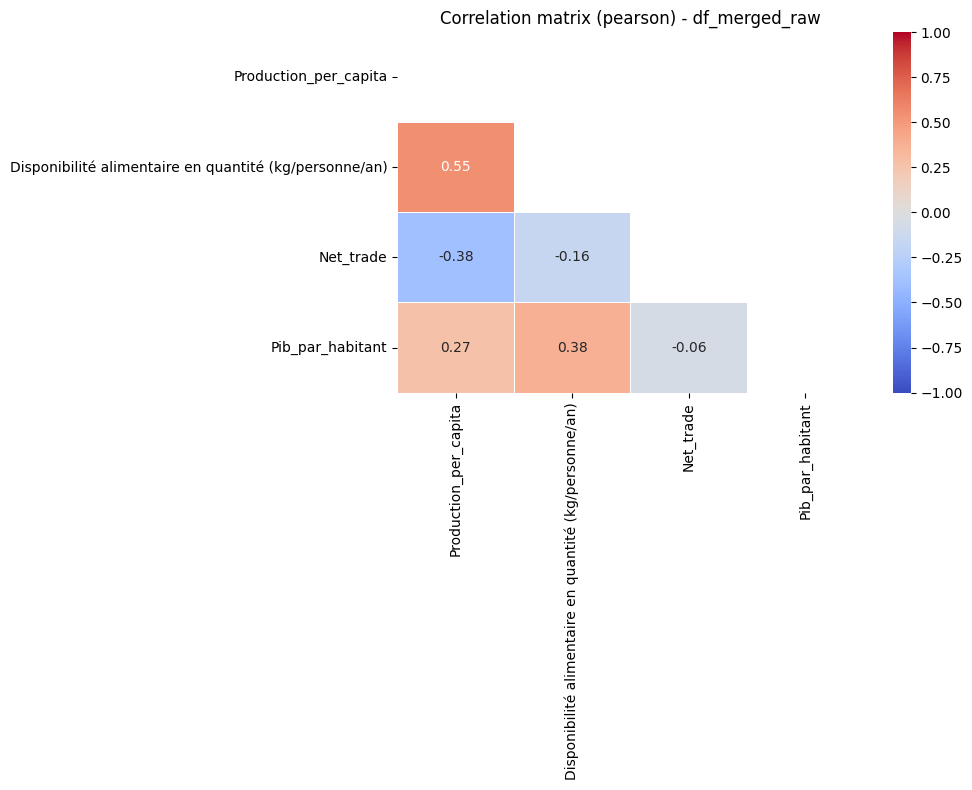

In [44]:
# 3) Heatmap de corrélation (choisir variables pertinentes)
candidate_vars = [
    'Production_per_capita','Disponibilité alimentaire en quantité (kg/personne/an)',
    'Net_trade','Pib_par_habitant','GDP_per_capita','Urban_pct','CO2_per_capita'
]
# Adapter noms selon colonnes réellement présentes
present = [c for c in candidate_vars if c in df_merged_raw.columns]

if len(present) >= 2:
    corr = df_merged_raw[present].corr(method='pearson')
    plt.figure(figsize=(10,8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, mask=mask, linewidths=.5)
    plt.title('Correlation matrix (pearson) - df_merged_raw')
    plt.tight_layout()


In [45]:
# Identifier les pays outliers par IQR

# Conserver index d'origine
if '_orig_index' not in df_merged_raw.columns:
    df_merged_raw = df_merged_raw.reset_index().rename(columns={'index':'_orig_index'})

# Colonnes numériques à analyser (exclure _orig_index et toute colonne log1p si présente)
num_cols = [c for c in df_merged_raw.select_dtypes(include=[np.number]).columns if c != '_orig_index' and not str(c).startswith('log1p_')]
print("Colonnes numériques analysées :", num_cols)

# Fonction IQR -> masque boolean
def iqr_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

# Construire flags d'outlier par ligne pour chaque variable
outlier_flags = pd.DataFrame(index=df_merged_raw.index)
for c in num_cols:
    # si colonne entièrement NaN, créer colonne de zéros
    if df_merged_raw[c].dropna().empty:
        outlier_flags[c + '_is_out'] = 0
    else:
        outlier_flags[c + '_is_out'] = iqr_mask(df_merged_raw[c]).astype(int)

# Indicateurs par ligne
outlier_flags['outlier_count_line'] = outlier_flags.sum(axis=1)
outlier_flags['_orig_index'] = df_merged_raw['_orig_index']
outlier_flags['Zone'] = df_merged_raw['Zone']

# Agrégation par pays
flag_cols = [col for col in outlier_flags.columns if col.endswith('_is_out')]
agg_sum_flags = outlier_flags.groupby('Zone')[flag_cols].sum().reset_index()
agg = pd.DataFrame()
agg['Zone'] = agg_sum_flags['Zone']
agg['total_outlier_flags'] = agg_sum_flags[flag_cols].sum(axis=1)
# nombre d'observations (lignes) avec au moins un flag
obs_with_flag = outlier_flags.groupby('Zone')['outlier_count_line'].apply(lambda s: (s>0).sum()).reset_index(name='n_obs_with_any_outlier')
agg = agg.merge(obs_with_flag, on='Zone')
# nombre de variables pour lesquelles le pays a au moins un outlier
agg['n_vars_with_any_outlier'] = (agg_sum_flags[flag_cols] > 0).sum(axis=1).values
# nombre total d'observations par pays
counts_by_zone = df_merged_raw.groupby('Zone').size().reset_index(name='n_obs_total')
agg = agg.merge(counts_by_zone, on='Zone', how='left')
agg['pct_obs_with_outlier'] = (agg['n_obs_with_any_outlier'] / agg['n_obs_total']).fillna(0) * 100

# Trier et afficher top pays
agg_sorted = agg.sort_values(['total_outlier_flags','n_obs_with_any_outlier'], ascending=False).reset_index(drop=True)
print("Top pays par nombre total de flags d'outlier")
display(agg_sorted.head(30))

# Afficher détails pour les top N pays
TOP_N = 20
top_countries = agg_sorted.head(TOP_N)['Zone'].tolist()
print(f"\nAffichage des observations outliers pour les top {TOP_N} pays :")
for country in top_countries:
    mask_country = (outlier_flags['Zone'] == country) & (outlier_flags['outlier_count_line'] > 0)
    if mask_country.any():
        print("\n---", country, "---")
        # afficher les lignes originales et les flags correspondants
        rows_idx = outlier_flags.loc[mask_country].index
        display(df_merged_raw.loc[rows_idx, ['_orig_index','Zone'] + num_cols].reset_index(drop=True))
        display(outlier_flags.loc[rows_idx, ['_orig_index','Zone','outlier_count_line'] + flag_cols].reset_index(drop=True))
    else:
        print("\n---", country, ": aucune observation marquée ---")

# Renvoyer les DataFrames pour réutilisation
outliers_country_summary = agg_sorted.copy()
outliers_line_flags = outlier_flags.copy()

# Afficher un résumé compact des pays les plus problématiques
print("\nRésumé compact top 20")
display(outliers_country_summary.head(20))


Colonnes numériques analysées : ['Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité intérieure', 'Importations - Quantité', 'Exportations - Quantité', 'Production', 'Population', 'Pib_par_habitant', 'Net_trade', 'Auto_sufficiency', 'Production_per_capita']
Top pays par nombre total de flags d'outlier


,Zone,total_outlier_flags,n_obs_with_any_outlier,n_vars_with_any_outlier,n_obs_total,pct_obs_with_outlier
0,Allemagne,7,1,7,1,100.0
1,États-Unis d'Amérique,7,1,7,1,100.0
2,Brésil,6,1,6,1,100.0
3,"Chine, continentale",6,1,6,1,100.0
4,Fédération de Russie,6,1,6,1,100.0
5,Pays-Bas,6,1,6,1,100.0
6,Pologne,6,1,6,1,100.0
7,Royaume-Uni de Grande-Bretagne et d'Irlande du...,6,1,6,1,100.0
8,Afrique du Sud,5,1,5,1,100.0
9,Belgique,5,1,5,1,100.0



Affichage des observations outliers pour les top 20 pays :

--- Allemagne ---


,_orig_index,Zone,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production,Population,Pib_par_habitant,Net_trade,Auto_sufficiency,Production_per_capita
0,4,Allemagne,19.47,1739.0,842.0,646.0,1514.0,82658.409,45282.0,196.0,0.870615,0.018316


,_orig_index,Zone,outlier_count_line,Disponibilité alimentaire en quantité (kg/personne/an)_is_out,Disponibilité intérieure_is_out,Importations - Quantité_is_out,Exportations - Quantité_is_out,Production_is_out,Population_is_out,Pib_par_habitant_is_out,Net_trade_is_out,Auto_sufficiency_is_out,Production_per_capita_is_out
0,4,Allemagne,7,0,1,1,1,1,1,1,1,0,0


...


--- Chine - RAS de Hong-Kong ---


,_orig_index,Zone,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production,Population,Pib_par_habitant,Net_trade,Auto_sufficiency,Production_per_capita
0,31,Chine - RAS de Hong-Kong,53.51,280.0,907.0,663.0,24.0,7306.322,45840.0,244.0,0.085714,0.003285


,_orig_index,Zone,outlier_count_line,Disponibilité alimentaire en quantité (kg/personne/an)_is_out,Disponibilité intérieure_is_out,Importations - Quantité_is_out,Exportations - Quantité_is_out,Production_is_out,Population_is_out,Pib_par_habitant_is_out,Net_trade_is_out,Auto_sufficiency_is_out,Production_per_capita_is_out
0,31,Chine - RAS de Hong-Kong,4,0,0,1,1,0,0,1,1,0,0



Résumé compact top 20


,Zone,total_outlier_flags,n_obs_with_any_outlier,n_vars_with_any_outlier,n_obs_total,pct_obs_with_outlier
0,Allemagne,7,1,7,1,100.0
1,États-Unis d'Amérique,7,1,7,1,100.0
2,Brésil,6,1,6,1,100.0
3,"Chine, continentale",6,1,6,1,100.0
4,Fédération de Russie,6,1,6,1,100.0
5,Pays-Bas,6,1,6,1,100.0
6,Pologne,6,1,6,1,100.0
7,Royaume-Uni de Grande-Bretagne et d'Irlande du...,6,1,6,1,100.0
8,Afrique du Sud,5,1,5,1,100.0
9,Belgique,5,1,5,1,100.0


In [46]:
# 1) Normaliser la colonne Zone (trim) et vérifier existence
if 'Zone' not in df_merged_raw.columns:
    raise KeyError("La colonne 'Zone' est introuvable dans df_merged_raw.")

df_merged_raw['Zone_clean'] = df_merged_raw['Zone'].astype(str).str.strip()

# 2) Repérer les lignes commençant par "Chine" (case sensitive ici ; adapter si besoin)
mask_chine_start = df_merged_raw['Zone_clean'].str.startswith('Chine', na=False)

# 3) Parmi celles-ci, identifier celles qui NE SONT PAS exactement 'Chine, continentale'
mask_to_drop = mask_chine_start & (df_merged_raw['Zone_clean'] != 'Chine, continentale')

# 4) Aperçu des lignes qui seront supprimées
n_drop = mask_to_drop.sum()
print(f"Lignes détectées commençant par 'Chine' à supprimer : {n_drop}")
if n_drop > 0:
    display(df_merged_raw.loc[mask_to_drop, ['_orig_index','Zone','Zone_clean'] + [c for c in df_merged_raw.columns if c not in ['Zone','Zone_clean']][:10]].head(200))

# 5) Suppression effective (création d'une copie filtrée pour sécurité)
df_filtered = df_merged_raw.loc[~mask_to_drop].copy()

# 6) remplacer df_merged_raw par la version filtrée
df_merged_raw = df_filtered


Lignes détectées commençant par 'Chine' à supprimer : 3


,_orig_index,Zone,Zone_clean,_orig_index,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Importations - Quantité,Exportations - Quantité,Production,Population,Pib_par_habitant,Net_trade,Auto_sufficiency
31,31,Chine - RAS de Hong-Kong,Chine - RAS de Hong-Kong,31,53.51,280.0,907.0,663.0,24.0,7306.322,45840.0,244.0,0.085714
32,32,Chine - RAS de Macao,Chine - RAS de Macao,32,34.47,19.0,23.0,0.0,3.0,622.585,77927.0,23.0,0.157895
33,33,"Chine, Taiwan Province de","Chine, Taiwan Province de",33,33.17,785.0,161.0,8.0,652.0,23674.546,0.0,153.0,0.830573


In [47]:
# Télécharger le fichier
df_merged_raw.to_csv('df_EDA_P11.csv', index=False)